# 1. 딥러닝

- 이번 Part 목표
1. 딥러닝, 전통 머신러닝의 관계 구분
2. 딥러닝에서 말하는 특징 학습이 무엇인지 설명
3. 입력 -> 예측 -> 손실 -> 가중치 수정 의 학습 흐름 이해
4. 하나의 가중치가 학습되는 과정을 숫자로 계산

---

# 2. 딥러닝 직관적 이해

### 2.1 딥러닝은 머신러닝의 한 종류이다.

관계를 간단히 표현하면

인공지능 ⊃ 머신러닝 ⊃ 딥러닝

- 머신러닝: 데이터를 이용해 규칙을 학습하는 방법
- 딥러닝: 여러 층으로 구성된 신경망을 이용하는 머신런이 방법

따라서 머신러닝과 딥러닝이 완전 별개의 분야는 아니다.

---

### 2.2 전통 머신러닝과 딥러닝의 차이

| 구분      | 전통 머신러닝                 | 딥러닝                        |
| ------- | ----------------------- | -------------------------- |
| 대표 모델   | KNN, SVM, Random Forest | MLP, CNN, RNN, Transformer |
| 입력      | 사람이 정리한 feature가 주로 사용됨 | 원본에 가까운 고차원 데이터도 사용 가능     |
| 특징 추출   | 사람의 전처리·설계 비중이 큼        | 신경망이 학습 과정에서 표현을 함께 학습     |
| 데이터 요구량 | 비교적 적은 데이터에서도 동작 가능     | 일반적으로 더 많은 데이터가 필요         |
| 연산량     | 상대적으로 작음                | 상대적으로 큼                    |
| 강점 데이터  | 표 형식 데이터, 소규모 데이터       | 이미지, 음성, 텍스트 등             |
| 엣지 배포   | 비교적 쉬움                  | 경량화와 가속이 중요                |

딥러닝이 언제나 더 좋은 것은 아니다.

EX:
> AP 별 RSSI 평균, 분산 
>
> 이미 잘 정리된 표 형식 데이터가 적게 있는 경우
>
> -> Random Forest, SVM 구조가 더 적잘할 수 있음

> 이미지의 픽셀, RSSI 시간 변화
>
> -> 딥러닝이 유용

---

### 2.3 특징 학습

EX: 고양이 이미지 분류

전통적인 접근: 사람이 아래와 같은 특징을 만들어 모델에 전달할 수 있음

- 색상 분포
- 윤곽선 개수
- 귀처럼 뾰족한 부분의 모양
- 특정 방향의 선분


딥러닝 CNN: 이미지 픽셀이나, RSSI 시간 변화처럼 입력 구조가 복잡하면 딥러닝이 유용할 가능성이 커진다.

- 앞부분 층: 선, 모서리처럼 단순한 패턴
- 중간 층: 질감이나 부분 구조
- 뒤쪽 층: 분류에 유용한 복합적인 형태

이를 **특징 학습** 또는 **표현 학습** 이라고 한다.

다만, 실제 신경망의 각 층이 만드시 사람이 이해할 수 있는 "귀", "눈"을 정확히 담당하는 것은 아니다.

신경망은 정답을 잘 예측하는 데 유용한 수치적 패턴을 학습한다.

---

# 3. 신경망 학습의 기본 수식

딥러닝 학습은 크게 네 단계로 정리 가능하다.

### 3.1 예측
입력 x를 모델에 넣어 예측값을 만든다.

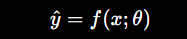

- x: 입력 데이터
- y: 실제 정답
- ^y: 모델의 예측
- f: 모델
- θ: 모델이 학습할 파라미터

여기서 파이미터는 가중치 w, 편향 b 같은 값이다.

---

### 3.2 손실 계산

예측과 정답의 차이를 손실함수로 계산한다.

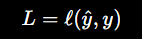

손실 L이 작을수록 현재 예측이 정답에 가깝다는 의미이다.

---

### 3.3 기울기 계산

손실을 줄이려면 가중치를 어느 방향으로 바꿔야 하는지 계산한다.

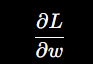

이 값을 가중치에 대한 손실의 기울기라고 한다.

---

### 3.4 가중치 수정

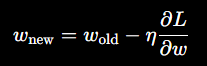

- η: Learning rate
- 기울기가 양수 -> 거중치 감소시킴
- 기울기가 음수 -> 가중치 증가시킴

---

# 실제 숫자로 계산해보기

편향이 없는 뉴런 하나를 가정하면

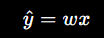

가정
- x = 2
- y = 3
- w = 0.5

### ① 예측
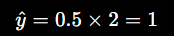

### ② 손실
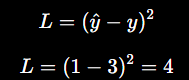

평균제곱오차의 간단한 형태 사용

### ③ 가중치의 기울기
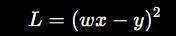

연쇄법칙으로 미분하면 다음과 같다.

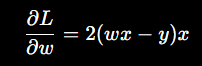

숫자 대입시

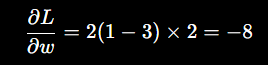

### ④ 가중치 수정

learning rate 를 0.1로 설정

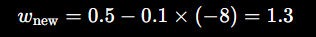

### ⑤ 새로운 예측과 손실

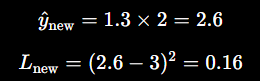

가중치가 0.5 -> 1.3 으로 바뀌면서 손실이 4 -> 1.6 으로 감소함

이것이 신경망 학습의 가장 작은 형태이다.

---

# 4. 실행 가능한 최소 PyTorch 코드

### 1. 실행 환경 확인

In [6]:
import torch
from torch import nn

torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Pytorch version:", torch.__version__)
print("Device:", device)

Pytorch version: 2.13.0+cu126
Device: cuda


---

### 셀 2: 가중치 한 번 학습시키기

가중치 w=0.5 로 예측하고, 손실의 기울기를 계산한 뒤, 가중치를 한 번 수정해서 손실이 줄어드는지 확인한다.

In [7]:
# 입력과 정답

x = torch.tensor([[2.0]], device=device)    # 모델에 넣을 입력
y = torch.tensor([[3.0]], device=device)    # 모델이 맞혀야 할 정답
# 대괄호가 2개 -> 모델이 일반적으로 데이터를
# [데이터 개수, 특성 개수] -> 이렇게 받기 때문이다.

# 입력 1개를 받아 출력 1개를 만드는 선형 모델
model = nn.Linear(
    in_features=1,  # 입력특성 1개
    out_features=1, # 출력값 1개
    bias=False      # 편향 b 사용하지 않음
).to(device)        # 모델의 가중치를 CPU 또는 GPU로 이동시킴

# 가중치를 0.5로 직접 설정
with torch.no_grad():       # Pytorch 에게 다음 블록 안에서는 기울기 추적을 끈 상태로 실행
    model.weight.fill_(0.5) # 함수 뒤의 _ => Pytorch에서 주로 원본 값은 직접 변경하는 in-place 연산

# 1. 예측
pred_before = model(x)

# 2. 손실 계산
loss_before = ((pred_before - y) ** 2).mean()   # 예측과 정답의 차이를 제곱한 평균 -> 평균제곱오차 MSE

# 3. 기울기 계산
model.zero_grad()       # 기존 기울기 초기화
loss_before.backward()  # backward => 손실값으로부터 역전파를 수행해 각 가중치의 기울기 계산

gradient = model.weight.grad.item()
# model.weight.grad => 일반 Python 숫자가 아니라 텐서

# item() 은 원소가 하나인 텐서에서 일반 Python 숫자를 꺼낸다
# item() 은 출력하거나 로그를 저장할 때 자주 사용함

# 4. 학습률 𝜂 설정
learning_rate = 0.1

# 5. 가중치 w 수정
with torch.no_grad():
    model.weight -= learning_rate * model.weight.grad
    # w_new = 0.5 - 0.1 * -8

# 6. 수정된 모델로 다시 예측
with torch.no_grad():
    pred_after = model(x)
    loss_after = ((pred_after - y) ** 2).mean()

print("수정 전 가중치:", 0.5)
print("계산된 기울기:", gradient)
print("수정 후 가중치:", model.weight.item())
print("수정 전 예측:", pred_before.item())
print("수정 후 예측:", pred_after.item())
print("수정 전 손실:",loss_before.item())
print("수정 후 손실:", loss_after.item())

수정 전 가중치: 0.5
계산된 기울기: -8.0
수정 후 가중치: 1.2999999523162842
수정 전 예측: 1.0
수정 후 예측: 2.5999999046325684
수정 전 손실: 4.0
수정 후 손실: 0.16000007092952728


계산이 정상이라면, 앞에서 작성한 계산값과 거의 같은 결과가 나온다.

---

# 5. 코드 역할과 Tensor shape

### 핵심 코드 설명

torch.tensor([[2.0]])           
- 입력 데이터를 Tensor로 생성

nn.Linear(1, 1, bias=False)     
- 입력 하나와 출력 하나를 연결하는 선형 모델 생성

model.weight.fill_(0.5)         
- 가중치를 실험값 0.5로 설정

pred_before = model(x)          
- 순전파를 수행하여 예측 계산

((pred_before-y)**2).mean()     
- 예측과 정답의 제곱 오차 계산

model.zero_grad()               
- 이전에 저장된 기울기를 초기화

loss_before.backward()          
- 손실로부터 각 파라미터의 기울기 계산

model.weight.grad               
- 가중치에 대해 계산된 기울기

model.weight -= learning_rate * model.weight.grad   
- 기울기를 이용해 가중치 수정

---

### Tensor shape

| Tensor | shape | 의미 | 
| ------ | ----- | ---- |
| x | [1, 1] | 샘플 1개, feature 1개 |
| y | [1, 1] | 샘플 1개의 정답 1개 |
| model.weight | [1, 1] | 출력 1개, 입력 1개 |
| pred_before | [1, 1] | 샘플 1개의 예측 1개 |
| loss_before | [] | 값 하나만 가진 scalar Tensor |
| model.weight.grad | [1, 1] | 가중치마다 하나씩 존재하는 기울기 |

---

다음 코드를 보면 위와 같다

In [12]:
print("x shape:", x.shape)
print("y shape:", y.shape)
print("weight shape:", model.weight.shape)
print("prediction shape:", pred_before.shape)
print("loss shape:", loss_before.shape)
print("gradient shape:", model.weight.grad.shape)

x shape: torch.Size([1, 1])
y shape: torch.Size([1, 1])
weight shape: torch.Size([1, 1])
prediction shape: torch.Size([1, 1])
loss shape: torch.Size([])
gradient shape: torch.Size([1, 1])


PyTorch의 nn.Linear 가중치 shape은 다음 순서를 활용한다.

> [out_features, in_features]

이 순서는 앞으로 자주 확인해야 한다.

---

# 6. 값을 바꿔보는 비교 실험

learning rate 만 바꾸면서 한 번의 학습 결과를 비교한다.

In [14]:
def run_one_step(learning_rate):
    model = nn.Linear(
        in_features=1,
        out_features=1,
        bias=False
    ).to(device)

    with torch.no_grad():
        model.weight.fill_(0.5)

    pred_before = model(x)
    loss_before = ((pred_before - y) ** 2).mean()

    model.zero_grad()
    loss_before.backward()

    gradient = model.weight.grad.item()

    with torch.no_grad():
        model.weight -= learning_rate * model.weight.grad
        pred_after = model(x)
        loss_after = ((pred_after - y) ** 2).mean()

    return {
        "learning_rate": learning_rate,
        "gradient": gradient,
        "new_weight": model.weight.item(),
        "new_prediction": pred_after.item(),
        "new_loss": loss_after.item()
    }

for lr in [0.01, 0.1, 0.3]:
    result = run_one_step(lr)
    print(result)

{'learning_rate': 0.01, 'gradient': -8.0, 'new_weight': 0.5799999833106995, 'new_prediction': 1.159999966621399, 'new_loss': 3.3856000900268555}
{'learning_rate': 0.1, 'gradient': -8.0, 'new_weight': 1.2999999523162842, 'new_prediction': 2.5999999046325684, 'new_loss': 0.16000007092952728}
{'learning_rate': 0.3, 'gradient': -8.0, 'new_weight': 2.9000000953674316, 'new_prediction': 5.800000190734863, 'new_loss': 7.840001106262207}


결과를 보고 아래를 생각해봐야 한다.

1. learning rate 가 달라도 처음 계산되는 기울기는 왜 같은가?

    기울기는 현재의 아래 값들로 계산된다.
    - 입력 x
    - 정답 y
    - 현재 가중치 w
    - 손실함수

    세 실험 모두 가중치를 0.5로 초기화한 후 기울기를 계산하므로 기울기는 항상 -8 이다.

    learning rate는 기울기를 계산할 때 사용되지 않고,

    계산된 기울기를 이용해 얼마나 변경할지 결정할 때 사용된다.

    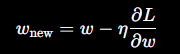

---

2. 0.01은 가중치를 얼마나 조금 수정했는가?

    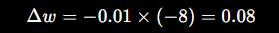

    따라서 가중치는 다음처럼 변경된다

    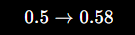

    새로운 예측은 다음과 같다

    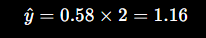

    새로운 손실은 다음과 같다

    

    손실이 4 => 3.3856 으로 감소했지만,

    가중치를 조금 변경했기 때문에 정답에 천천히 접근한다.

---

3. 0.3에서는 손실이 오히려 커지는가?

    가중치 변화량은 다음과 같다

    

    따라서 가중치는 다음처럼 크게 변경된다

    

    새로운 예측은 다음과 같다

    

    손실은 다음과 같다

    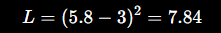

    따라서 손실이 실제로 다음처럼 커진다

    

    이 문제에서 정답을 정확하게 예측하는 최적 가중치는 다음과 같다.

    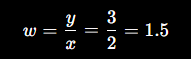

    하지만, learning rate 가 너무 커서 가중치가 0.5 => 2.9 로 이동하면서 최적값 1.5 를 지나쳤다.

    이를 overshooting 이라고 한다

---

4. learning rate가 크면 항상 빨리 학습된다고 할 수 있는가?

    그렇지 않다.
    - 너무 작음: 손실은 안정적으로 감소하지만 학습이 느리다
    - 적절: 손실이 빠르고 안정적으로 감소한다
    - 너무 큼: 최적점을 계속 지나쳐 손실이 진동하거나 증가할 수 있다
    - 매우 큼: 손실이 계속 커지며 학습이 발산할 수 있다


    | Learning rate | 새 가중치 | 새 예측 |   새 손실 | 해석             |
    | ------------: | ----: | ---: | -----: | -------------- |
    |          0.01 |  0.58 | 1.16 | 3.3856 | 안정적이지만 변화가 작음  |
    |           0.1 |   1.3 |  2.6 |   0.16 | 최적값에 적절히 접근    |
    |           0.3 |   2.9 |  5.8 |   7.84 | 최적값을 지나쳐 손실 증가 |

### 핵심
> 기울기는 가중치를 변경할 방향과 상대적인 크기를 알려주고, learning rate 는 그 방향으로 실제로 얼마나 이동할지를 결정함

---

# 7. 실습

### 7.1 계산

아래의 조건 사용
- x = 3
- y = 7
- w = 1
- η = 0.05

계산할 값
1. 수정 전 예측값 ^y
2. 수정 전 손실 L
3. 기울기 ∂w/∂L
4. 수정 후 가중치 w_new
5. 수정 후 예측값
6. 수정 후 손실

사용할 식은 아래와 같다.

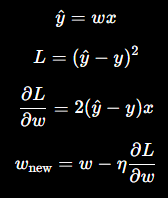

직접 계산한 뒤, 

셀 2의 x, y, 초기 가중치, learning rate 를 수정해서 확인하면 된다.

### 직접 계산시

1. w*x = 3
2. (^y - y)**2 = 16
3. ∂L/∂w  = 2(^y - y)*x = -24
4. w_new = w - η * (∂L/∂w) = 1 + 1.12 = 2.2

In [15]:
# 입력과 정답
x = torch.tensor([[3.0]], device=device)    # 모델에 넣을 입력
y = torch.tensor([[7.0]], device=device)    # 모델이 맞혀야 할 정답
# 대괄호가 2개 -> 모델이 일반적으로 데이터를
# [데이터 개수, 특성 개수] -> 이렇게 받기 때문이다.

# 입력 1개를 받아 출력 1개를 만드는 선형 모델
model = nn.Linear(
    in_features=1,  # 입력특성 1개
    out_features=1, # 출력값 1개
    bias=False      # 편향 b 사용하지 않음
).to(device)        # 모델의 가중치를 CPU 또는 GPU로 이동시킴

# 가중치를 0.5로 직접 설정
with torch.no_grad():       # Pytorch 에게 다음 블록 안에서는 기울기 추적을 끈 상태로 실행
    model.weight.fill_(1.0) # 함수 뒤의 _ => Pytorch에서 주로 원본 값은 직접 변경하는 in-place 연산

# 1. 예측
pred_before = model(x)

# 2. 손실 계산
loss_before = ((pred_before - y) ** 2).mean()   # 예측과 정답의 차이를 제곱한 평균 -> 평균제곱오차 MSE

# 3. 기울기 계산
model.zero_grad()       # 기존 기울기 초기화
loss_before.backward()  # backward => 손실값으로부터 역전파를 수행해 각 가중치의 기울기 계산

gradient = model.weight.grad.item()
# model.weight.grad => 일반 Python 숫자가 아니라 텐서

# item() 은 원소가 하나인 텐서에서 일반 Python 숫자를 꺼낸다
# item() 은 출력하거나 로그를 저장할 때 자주 사용함

# 4. 학습률 𝜂 설정
learning_rate = 0.05

# 5. 가중치 w 수정
with torch.no_grad():
    model.weight -= learning_rate * model.weight.grad
    # w_new = 0.5 - 0.1 * -8

# 6. 수정된 모델로 다시 예측
with torch.no_grad():
    pred_after = model(x)
    loss_after = ((pred_after - y) ** 2).mean()

print("수정 전 가중치:", 0.5)
print("계산된 기울기:", gradient)
print("수정 후 가중치:", model.weight.item())
print("수정 전 예측:", pred_before.item())
print("수정 후 예측:", pred_after.item())
print("수정 전 손실:",loss_before.item())
print("수정 후 손실:", loss_after.item())

수정 전 가중치: 0.5
계산된 기울기: -24.0
수정 후 가중치: 2.200000047683716
수정 전 예측: 3.0
수정 후 예측: 6.600000381469727
수정 전 손실: 16.0
수정 후 손실: 0.15999969840049744


---

# 요약

- 딥러닝은 신경망을 사용하는 머신러닝 방법이다
- 전통 머신러닝은 정리된 feature 를 주로 사용하고, 딥러닝은 복잡한 입력에서 유용한 표현을 함께 학습할 수 있다.
- 모델은 입력을 받아 예측값을 만든다.
- 손실함수는 예측과 정답의 차이를 수치화한다.
- 미분으로 손실을 줄일 가중치 수정 방향을 구한다.
- learning rate는 한 번에 가중치를 얼마나 수정할지 결정한다.
- 딥러닝이 항상 전통 머신러닝보다 좋은 것은 아니다